In [16]:
import catboost
from catboost import CatBoostClassifier, CatBoostRegressor
import catboost.datasets

import math
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import shap

shap.initjs()

In [2]:
X, y = shap.datasets.california(n_points=500)
df = X.copy()
df["MedHouseVal"] = y
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
14740,4.1518,22.0,5.663073,1.075472,1551.0,4.180593,32.58,-117.05,1.369
10101,5.7796,32.0,6.107226,0.927739,1296.0,3.020979,33.92,-117.97,2.413
20566,4.3487,29.0,5.930712,1.026217,1554.0,2.910112,38.65,-121.84,2.007
2670,2.4511,37.0,4.992958,1.316901,390.0,2.746479,33.20,-115.60,0.725
15709,5.0049,25.0,4.319261,1.039578,649.0,1.712401,37.79,-122.43,4.600


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
 )

X_train.shape, X_test.shape

((400, 8), (100, 8))

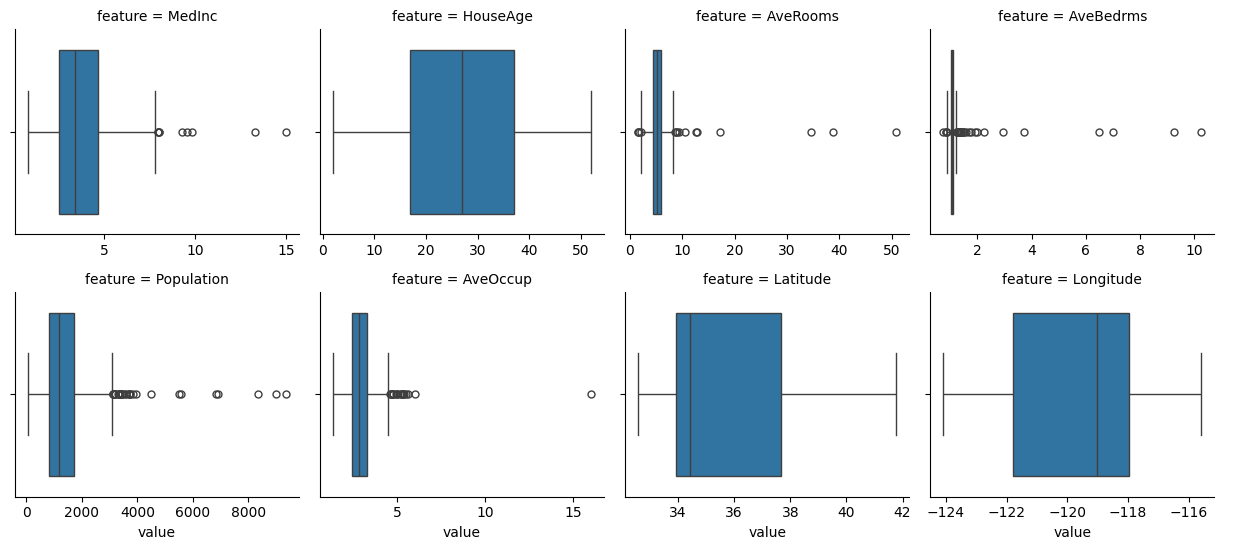

In [4]:
num = X.select_dtypes(include="number")
if num.shape[1] == 0:
    raise ValueError("X has no numeric columns to plot.")

max_cols_per_fig = 12
col_wrap = 4

for start in range(0, num.shape[1], max_cols_per_fig):
    cols = num.columns[start:start + max_cols_per_fig]
    long_df = num[cols].melt(var_name="feature", value_name="value")

    g = sns.catplot(
        data=long_df,
        x="value",
        # y="feature",
        col="feature",
        kind="box",
        col_wrap=col_wrap,
        sharex=False,
        sharey=False,
        height=2.8,
        aspect=1.1,
    )


<Axes: xlabel='MedHouseVal', ylabel='Count'>

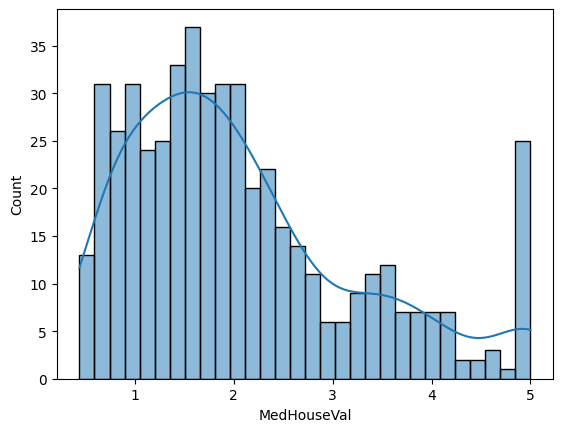

In [5]:
sns.histplot(df["MedHouseVal"], bins=30, kde=True)

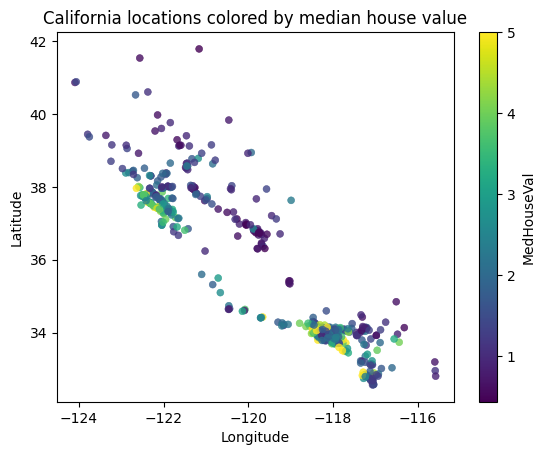

In [6]:
norm = mpl.colors.Normalize(vmin=df["MedHouseVal"].min(), vmax=df["MedHouseVal"].max())

ax = sns.scatterplot(
    data=df,
    x="Longitude",
    y="Latitude",
    hue="MedHouseVal",
    palette="viridis",
    hue_norm=norm,
    legend=False,
    s=25,
    alpha=0.8,
    edgecolor=None,
 )
ax.set_title("California locations colored by median house value")

sm = mpl.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])
ax.figure.colorbar(sm, ax=ax, label="MedHouseVal")

In [7]:
model = CatBoostRegressor(iterations=300, learning_rate=0.1, random_seed=123)
model.fit(X_train, y_train, verbose=False, plot=False)

pred_train = model.predict(X_train)
pred_test = model.predict(X_test)

metrics = pd.DataFrame(
    {
        "split": ["train", "test"],
        "MAE": [
            mean_absolute_error(y_train, pred_train),
            mean_absolute_error(y_test, pred_test),
        ],
        "RMSE": [
            mean_squared_error(y_train, pred_train) ** 0.5,
            mean_squared_error(y_test, pred_test) ** 0.5,
        ],
        "R2": [
            r2_score(y_train, pred_train),
            r2_score(y_test, pred_test),
        ],
    }
)
metrics

,split,MAE,RMSE,R2
0,train,0.105142,0.135004,0.986144
1,test,0.491341,0.686213,0.692426


In [8]:
y_train[0]

np.float64(1.464)

<Axes: >

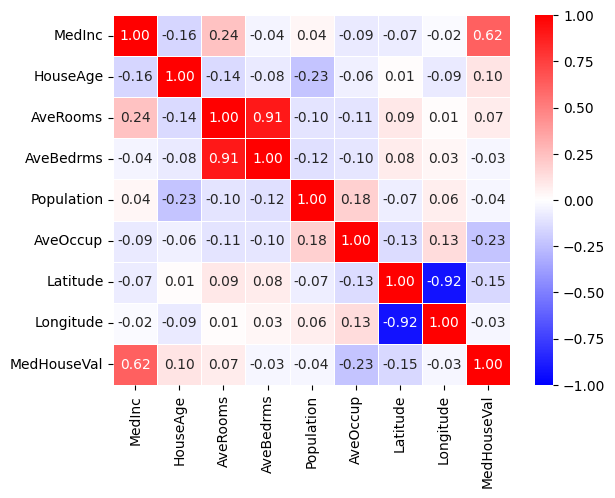

In [9]:
sns.heatmap(df.corr(), cmap="bwr", vmin=-1, vmax=1, annot=True, fmt=".2f", linewidths=0.5)

In [13]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_train)

shap.plots.force(
shap_values[0,...]
)

In [11]:
shap.plots.force(shap_values)

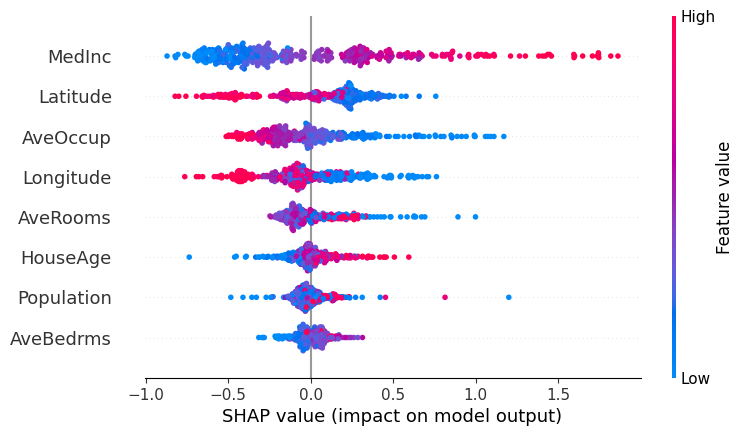

In [14]:
shap.plots.beeswarm(shap_values)

In [18]:
train_df, test_df = catboost.datasets.amazon()
y = train_df.ACTION
X = train_df.drop("ACTION", axis=1)
cat_features = list(range(0, X.shape[1]))

RuntimeError: ('failed to download from %s', ('https://storage.mds.yandex.net/get-devtools-opensource/250854/amazon.tar.gz',))

In [ ]:
cat_features

In [ ]:
num = X.select_dtypes(include="number")
if num.shape[1] == 0:
    raise ValueError("X has no numeric columns to plot.")

max_cols_per_fig = 12
col_wrap = 4

for start in range(0, num.shape[1], max_cols_per_fig):
    cols = num.columns[start:start + max_cols_per_fig]
    long_df = num[cols].melt(var_name="feature", value_name="value")

    g = sns.catplot(
        data=long_df,
        x="value",
        # y="feature",
        col="feature",
        kind="box",
        col_wrap=col_wrap,
        sharex=False,
        sharey=False,
        height=2.8,
        aspect=1.1,
    )